<a href="https://colab.research.google.com/github/payalkamble219-code/ECommerce-Orders-Analysis/blob/main/ECommerce_Orders_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# E-Commerce Orders Analysis

### Project Objective

The objective of this project is to analyze e-commerce order data
to identify order trends, customer behavior, and geographical
patterns using Python and data visualization.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv("/content/List of Orders (11).csv")

In [3]:
orders.head()

,Order ID,Order Date,CustomerName,State,City
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad
1,B-25602,01-04-2018,Pearl,Maharashtra,Pune
2,B-25603,03-04-2018,Jahan,Madhya Pradesh,Bhopal
3,B-25604,03-04-2018,Divsha,Rajasthan,Jaipur
4,B-25605,05-04-2018,Kasheen,West Bengal,Kolkata


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 22.0+ KB


In [5]:
orders.shape

(560, 5)

In [6]:
orders.columns

Index(['Order ID', 'Order Date', 'CustomerName', 'State', 'City'], dtype='object')

In [7]:
orders.shape

(560, 5)

In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 22.0+ KB


## Data Cleaning

The dataset was checked for missing values, duplicate records, and incorrect data types.

In [9]:
orders.isnull().sum()

,0
Order ID,60
Order Date,60
CustomerName,60
State,60
City,60


In [10]:
orders = orders.dropna(how="all")

In [11]:
orders.duplicated().sum()

np.int64(0)

In [13]:
orders["Order Date"] = pd.to_datetime(orders["Order Date"], format="%d-%m-%Y")

In [14]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      500 non-null    object        
 1   Order Date    500 non-null    datetime64[ns]
 2   CustomerName  500 non-null    object        
 3   State         500 non-null    object        
 4   City          500 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 23.4+ KB


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand order patterns,
customer distribution, and geographical trends in the dataset.

In [16]:
orders.describe (include="all")

,Order ID,Order Date,CustomerName,State,City
count,500,500,500,500,500
unique,500,NaN,332,19,24
top,B-26100,NaN,Shreya,Madhya Pradesh,Indore
freq,1,NaN,6,101,76
mean,NaN,2018-10-21 11:11:02.400000256,NaN,NaN,NaN
min,NaN,2018-04-01 00:00:00,NaN,NaN,NaN
25%,NaN,2018-07-20 18:00:00,NaN,NaN,NaN
50%,NaN,2018-11-05 12:00:00,NaN,NaN,NaN
75%,NaN,2019-01-25 00:00:00,NaN,NaN,NaN
max,NaN,2019-03-31 00:00:00,NaN,NaN,NaN


### 1. State-wise Order Analysis

This analysis identifies the number of orders received from each state
and helps understand the geographical distribution of orders.

In [17]:
state_orders = orders["State"].value_counts()
state_orders

,count
State,
Madhya Pradesh,101
Maharashtra,90
Rajasthan,32
Gujarat,27
Punjab,25
Uttar Pradesh,22
West Bengal,22
Delhi,22
Karnataka,21


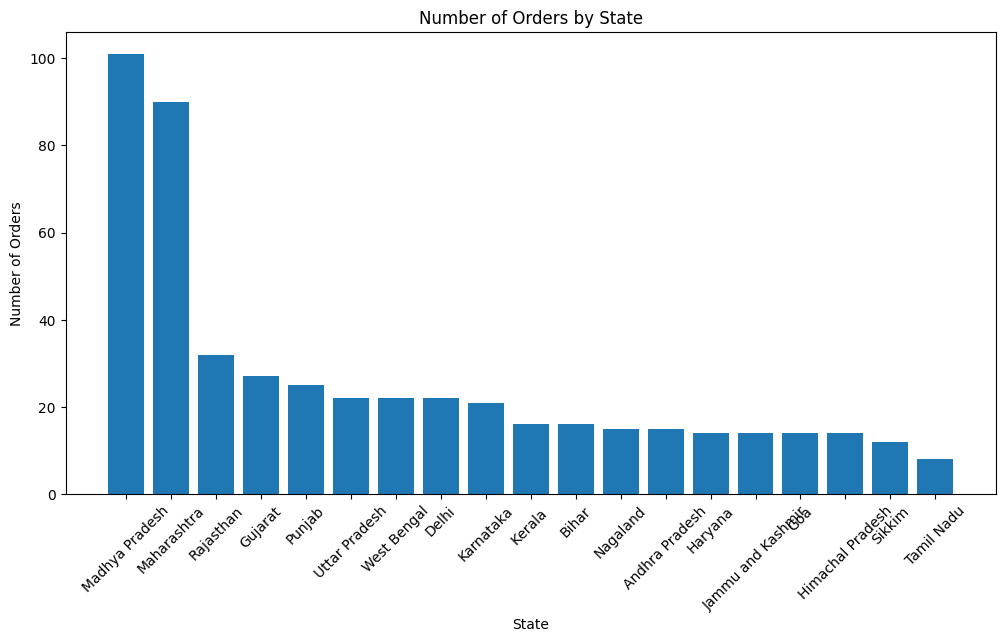

In [18]:
plt.figure(figsize=(12,6))

plt.bar(state_orders.index, state_orders.values)

plt.xlabel("State")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by State")

plt.xticks(rotation=45)
plt.show()

### Insight

Madhya Pradesh has the highest number of orders, followed by Maharashtra.
This indicates that these states contribute significantly to the overall
order volume in the dataset.

### 2. Top 10 Cities by Orders

This analysis identifies the top 10 cities based on the number of orders
and helps understand where the highest order activity is concentrated.

In [19]:
city_orders = orders["City"].value_counts().head(10)

city_orders

,count
City,
Indore,76
Mumbai,68
Chandigarh,30
Delhi,25
Pune,22
Bhopal,22
Kolkata,22
Bangalore,21
Jaipur,19


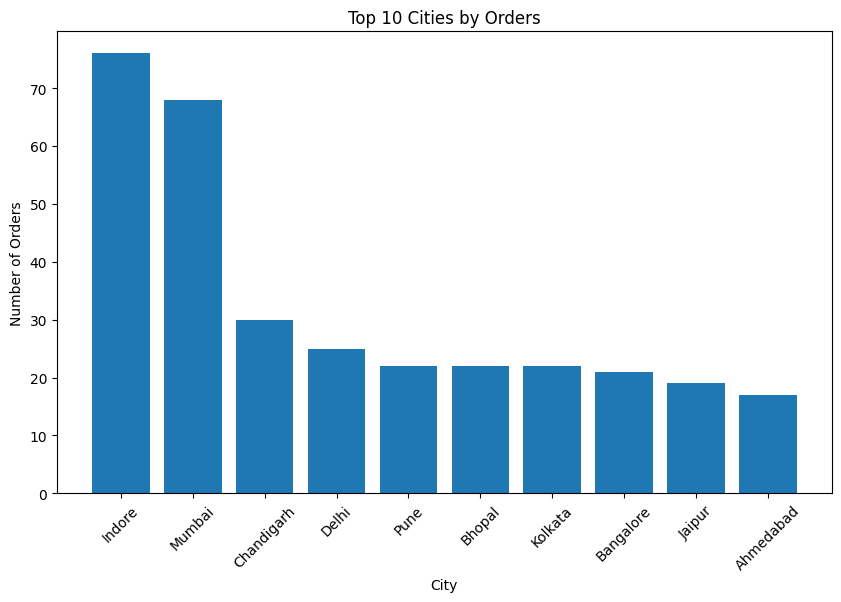

In [20]:
plt.figure(figsize=(10,6))

plt.bar(city_orders.index, city_orders.values)

plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.title("Top 10 Cities by Orders")

plt.xticks(rotation=45)
plt.show()

### Insight

Indore has the highest number of orders with 76 orders, followed by Mumbai
with 68 orders. Chandigarh ranks third with 30 orders.

The order volume is highly concentrated in the top two cities, indicating
that these cities are important markets in the dataset.

### 3. Monthly Order Trend

This analysis shows how the number of orders changed month by month
during the period covered by the dataset.

In [21]:
orders["Month"] = orders["Order Date"].dt.to_period("M")

monthly_orders = orders["Month"].value_counts().sort_index()

monthly_orders

,count
Month,
2018-04,44
2018-05,31
2018-06,30
2018-07,31
2018-08,31
2018-09,30
2018-10,43
2018-11,46
2018-12,41


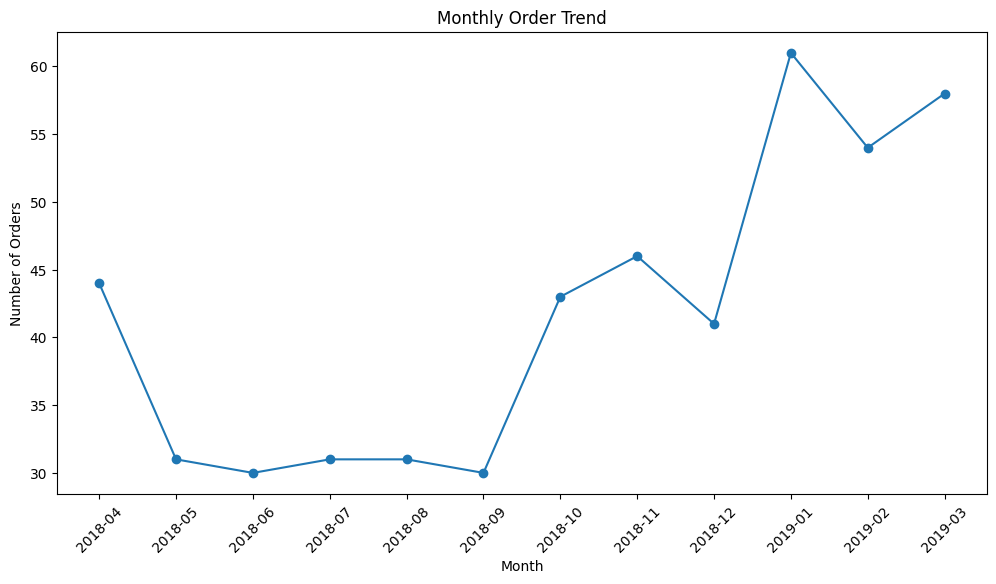

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_orders.index.astype(str),
    monthly_orders.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Order Trend")

plt.xticks(rotation=45)
plt.show()

### Insight

Order volume fluctuated throughout the year. January 2019 recorded the
highest number of orders with 61 orders, while June and September 2018
recorded the lowest with 30 orders each.

Order volume increased noticeably from October 2018 onwards, with January
2019 showing the highest activity.

### 4. Top 10 Customers by Orders

This analysis identifies the customers who placed the highest number
of orders in the dataset.

In [23]:
customer_orders = orders["CustomerName"].value_counts().head(10)

customer_orders

,count
CustomerName,
Shreya,6
Abhishek,5
Pooja,5
Shubham,5
Rohan,4
Priyanka,4
Shruti,4
Yogesh,4
Sheetal,4


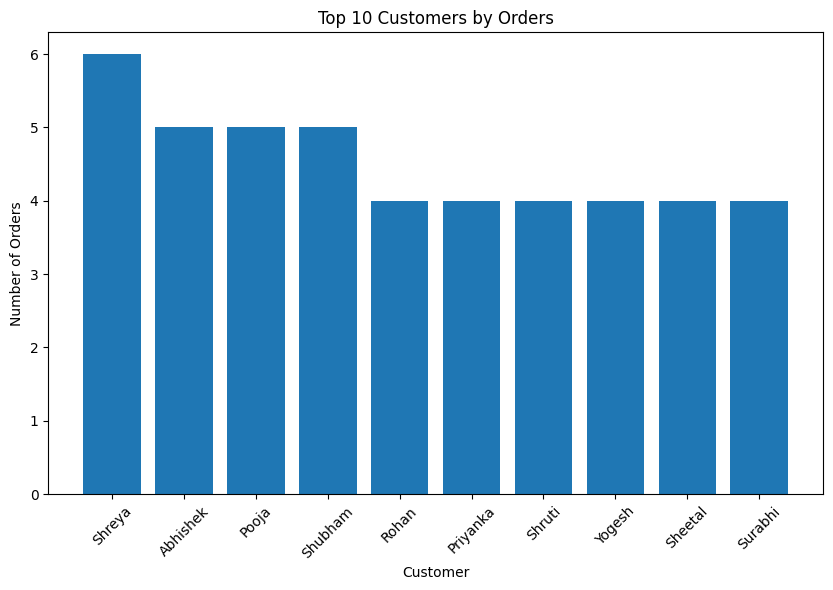

In [24]:
plt.figure(figsize=(10,6))

plt.bar(customer_orders.index, customer_orders.values)

plt.xlabel("Customer")
plt.ylabel("Number of Orders")
plt.title("Top 10 Customers by Orders")

plt.xticks(rotation=45)
plt.show()

### Insight

Shreya is the most frequent customer in the dataset with 6 orders.
Abhishek, Pooja, and Shubham follow with 5 orders each.

The top customers have relatively similar order frequencies, indicating
that no single customer dominates the order volume.

## Key Insights

1. Madhya Pradesh recorded the highest number of orders with 101 orders,
   followed by Maharashtra with 90 orders.

2. Indore was the top city with 76 orders, followed by Mumbai with 68 orders.

3. January 2019 recorded the highest monthly order volume with 61 orders.

4. Shreya was the most frequent customer in the dataset with 6 orders.

5. Order activity was concentrated in a few major states and cities,
   indicating that these locations are important markets in the dataset.

## Business Recommendations

- Focus marketing efforts on high-order states such as Madhya Pradesh
  and Maharashtra.

- Strengthen customer engagement in high-order cities such as Indore
  and Mumbai.

- Analyze periods with high order activity and consider targeted
  promotions during similar periods.

- Develop customer retention strategies for frequent customers.

## Project Summary

This project analyzed e-commerce order data using Python and Pandas.
The analysis focused on data cleaning, order distribution by state and city,
monthly order trends, and customer order frequency.

The visualizations helped identify important geographical and temporal
patterns in the order data.